In [1]:
import ast
import glob
import warnings
from collections import defaultdict
from datetime import date

import numpy as np
import pandas as pd
import wandb

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import os
import json


today = date.today()
api = wandb.Api()

# # Find all csv files in the current directory
csv_files = glob.glob("csv/*.csv")
# # Collect all the names of the csv files without the extension
csv_names = [csv_file[:-4] for csv_file in csv_files]
project_name = "6g_December3"  
user = "telyatnikov_sap"

if project_name not in csv_names:
    runs = api.runs(f"{user}/{project_name}")

    summary_list, config_list, name_list = [], [], []
    for run in runs:
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)

        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k, v in run.config.items() if not k.startswith("_")}
        )

        # .name is the human-readable name of the run.
        name_list.append(run.name)

    runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

    runs_df.to_csv(f"csv/{user}_{project_name}.csv")
else:
    runs_df = pd.read_csv(f"csv/{user}_{project_name}.csv", index_col=0)

    for row in runs_df.iloc:
        row["summary"] = ast.literal_eval(row["summary"])
        row["config"] = ast.literal_eval(row["config"])


for row in runs_df.iloc:
    row["summary"].update(row["config"])

lst = [i["summary"] for i in runs_df.iloc]
df = pd.DataFrame.from_dict(lst)

df_init = df.copy()

# drop row 0
#df = df.drop(df.index[-1])

In [2]:
def normalize_column(df, column_to_normalize):
    # Use json_normalize to flatten the nested dictionaries into separate columns
    flattened_df = pd.json_normalize(df[column_to_normalize])
    # Rename columns to include 'nested_column' prefix
    flattened_df.columns = [
        f"{column_to_normalize}.{col}" for col in flattened_df.columns
    ]
    # Concatenate the flattened DataFrame with the original DataFrame
    result_df = pd.concat([df, flattened_df], axis=1)
    # Get new columns names
    new_columns = flattened_df.columns
    # Drop the original nested column if needed
    result_df.drop(column_to_normalize, axis=1, inplace=True)
    return result_df, new_columns


# Config columns to normalize
columns_to_normalize = ["decoder", 'compressor']
# df.fillna('NA', inplace=True)
# df = df[df['test/loss'] != 'NA']
# Keep track of config columns added
config_columns = []
for column in columns_to_normalize:
    df, columns = normalize_column(df, column)
    config_columns.extend(columns)



# substitute NaN with 'NA'
df.fillna('NA', inplace=True)
#df = df[df['Elements compression'] != 'NA']
df = df[df['compressor.name'] != 'NA'] 
df['compressor.r'] = df['compressor.r'].apply(lambda x: str(x))
#df['Elements compression'] = df['Elements compression'].apply(lambda x: np.round((1 - x)*100))
# Rename No Compression to VIT

# First rename conditional cases: 
df.loc[(df['compressor.name'] == 'AE'), 'compressor.name'] = 'AE'
df.loc[(df['compressor.name'] == 'AE+gnn'), 'compressor.name'] = 'AE_GNN'

# Second rename conditional cases: 
df.loc[(df['compressor.name'] == 'tome'), 'compressor.name'] = 'TOME'
df.loc[(df['compressor.name'] == 'tome_gnn'), 'compressor.name'] = 'TOME_GNN'



In [3]:

# df.experiments_dir df.experiment_name
# Go over the rows and create path
new_col = []
for i, row in df.iterrows():
    new_col.append(f"{row['experiments_dir']}{row['experiment_name']}")

df['path'] = new_col

In [4]:
df['path'].head(5)

0    log/runs/2024-12-20-23-49-41
1    log/runs/2024-12-20-23-19-31
2    log/runs/2024-12-20-22-49-07
3    log/runs/2024-12-20-22-18-56
4    log/runs/2024-12-20-21-48-42
Name: path, dtype: object

In [5]:
df.columns

Index(['Elements compression rate (mine)', 'Elements compression rate (n/k)',
       'Elements to send', 'Token compression rate', 'Tokens to send',
       '_runtime', '_step', '_timestamp', '_wandb', 'test/accuracy',
       'test/classification_loss', 'test/loss', 'test/mse',
       'train/classification_loss', 'train/mse_loss', 'train/total_loss',
       'val/accuracy', 'val/best_accuracy', 'val/best_classification_loss',
       'val/best_loss', 'val/best_mse', 'val/classification_loss', 'val/loss',
       'val/mse', 'loss', 'seed', 'noise', 'device', 'logger', 'dataset',
       'encoder', 'training', 'load_from', 'optimizer', 'workspace',
       'ch_decoder', 'ch_encoder', 'train_snr_db', 'experiment_name',
       'experiments_dir', 'validate_snr_db', 'refinment_blocks',
       'transmit_cls_token', 'classifier_num_blocks', 'decoder.mlp_dim',
       'decoder._target_', 'decoder.num_heads', 'decoder.hidden_dim',
       'decoder.image_size', 'decoder.num_layers', 'decoder.patch_size',

/tmp/ipykernel_2665568/390054239.py:124: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


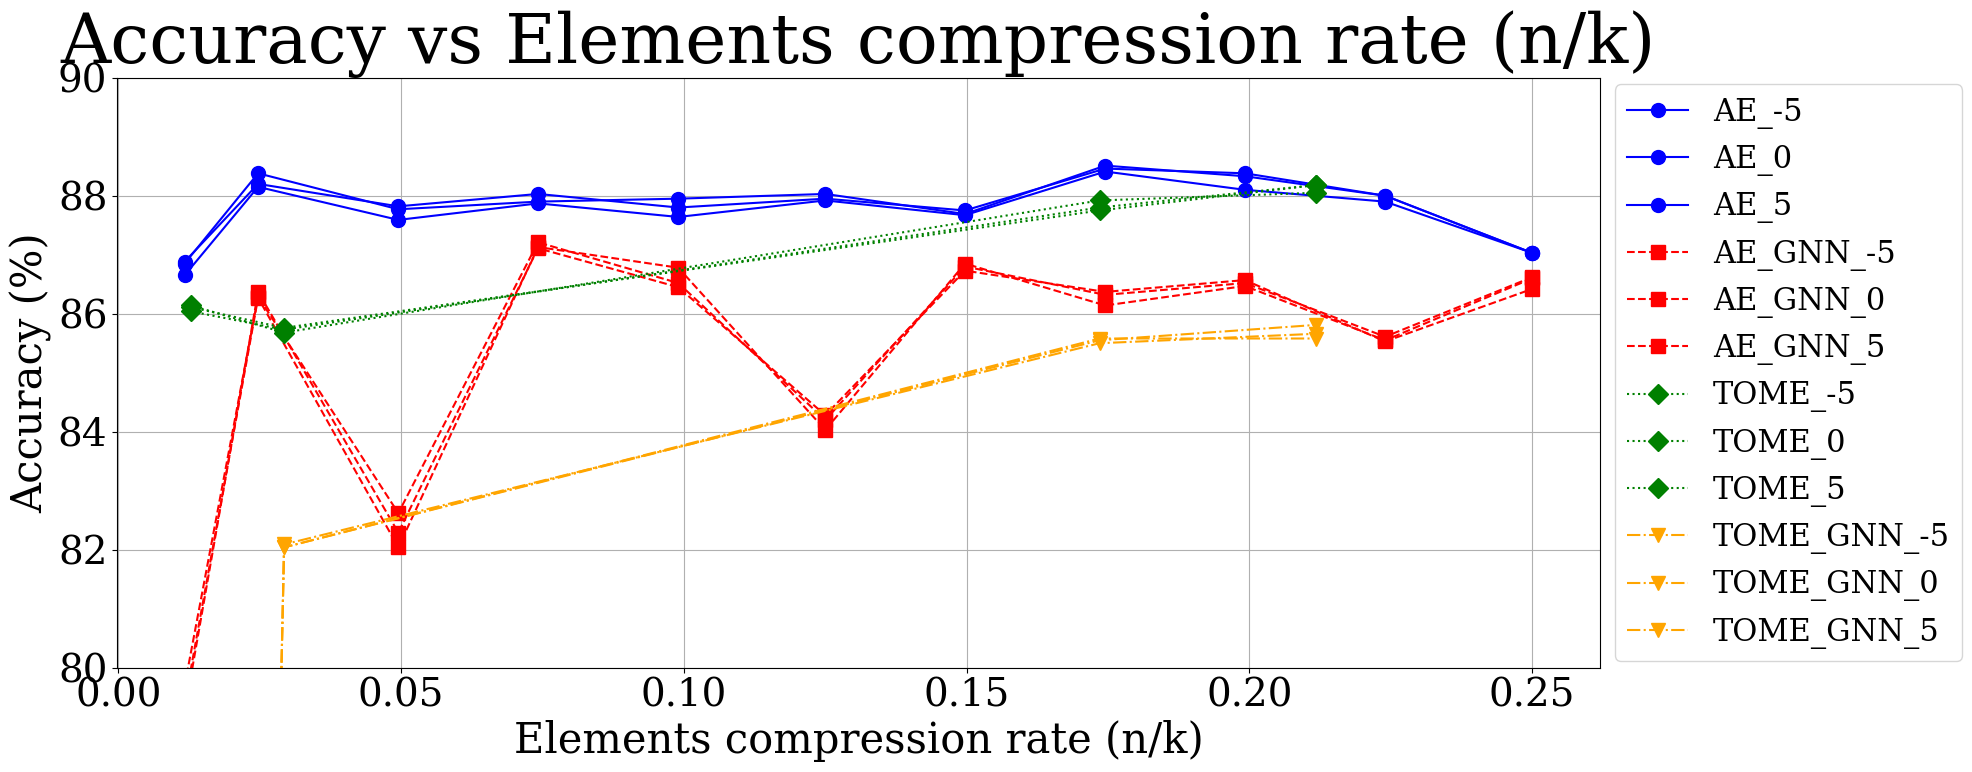

In [33]:
# Plotting settings
settings = {
    'font.family': 'serif',
    'text.latex.preamble': '\\renewcommand{\\rmdefault}{ptm}\\renewcommand{\\sfdefault}{phv}',
    'figure.figsize': (20, 8),  # Adjusted figure size for two columns
    'figure.constrained_layout.use': True,
    'figure.autolayout': False,
    'font.size': 16,
    'axes.labelsize': 30,
    'legend.fontsize': 22,
    'xtick.labelsize': 28,
    'ytick.labelsize': 28,
    'axes.titlesize': 50
}

COMPRESSION_MEASURE = 'Elements compression rate (n/k)'

shared_sweep_columns = [
    'compressor.name', 
    #'train_classifier_separetely', 
    'train_snr_db', 
    COMPRESSION_MEASURE,
    #'Elements compression rate (n/k)'
]

personalised_sweep_columns = {
    'AE':['compressor.encoding_dim'] + shared_sweep_columns,
    'AE_GNN':['compressor.encoding_dim'] + shared_sweep_columns,
    
    'TOME': ['compressor.r'] + shared_sweep_columns,
    'TOME_GNN': ['compressor.r'] + shared_sweep_columns,
}

models = ['AE', 'AE_GNN', 'TOME', 'TOME_GNN']
# assign model line typees
line_types = {
    'AE': 'solid',
    'AE_GNN': 'dashed',
    'TOME': 'dotted',
    'TOME_GNN': 'dashdot'
}
# assign model dots typees
dots_types = {
    'AE': 'o',
    'AE_GNN': 's',
    'TOME': 'D',
    'TOME_GNN': 'v'
}
# assign snr colors
snr_colors = {
    'AE': 'blue',
    'AE_GNN': 'red',
    'TOME': 'green',
    'TOME_GNN': 'orange'
}

res_to_plot = {}

df_copy = df.copy()
with plt.rc_context(settings):
    
    
    for compressor_name in models:
        compressor_df = df.loc[df['compressor.name'] == compressor_name]
        sweep_columns = personalised_sweep_columns[compressor_name]
        unique_combinations = compressor_df[sweep_columns].drop_duplicates()
        

        data_collect = {}
        for idx, combination in unique_combinations.iterrows():
            selected_idx = [df_copy[key] == val for key, val in combination.items()]
            mask = np.logical_and.reduce(selected_idx)
            subset = df_copy[mask]
            path_to_json = os.path.join(subset['path'].item(), 'results.json')

            # Load and plot results
            with open(path_to_json, 'r') as f:
                results = json.load(f)

            snr = np.array(list(results.keys())).astype(float)
            accuracy = np.array([results[key]['test/accuracy'] * 100 for key in results.keys()]).round(2)
            
            # Collect resuolts
            data_collect[combination[COMPRESSION_MEASURE]] = dict(zip(snr, accuracy))
        res_to_plot[compressor_name] = data_collect
    
    # Simplify plotting curves
    plotting_curves = {}
    snrs = [-5, 0, 5]
    for compressor_name in models:
        x_values = list(res_to_plot[compressor_name].keys())

        for snr in snrs:
            curve_name = f"{compressor_name}_{snr}"
            y_values = [res_to_plot[compressor_name][x][snr] for x in x_values]

            # sort x_values and y_values in ascending order of x_values
            x_values, y_values = zip(*sorted(zip(x_values, y_values)))
            plotting_curves[curve_name] = (x_values, y_values)
    
    # Plotting
    fig, ax = plt.subplots()
    for curve_name, (x_values, y_values) in plotting_curves.items():
        ax.plot(x_values, y_values, label=curve_name)
        ax.set_xlabel('Elements compression rate (n/k)')
        ax.set_ylabel('Accuracy (%)')
        ax.set_title('Accuracy vs Elements compression rate (n/k)')
        ax.grid(True)
        ax.legend()
        #  apply colors to the lines

        curve_name = "_".join(curve_name.split('_')[:-1])
        ax.lines[-1].set_color(snr_colors[curve_name])
        ax.lines[-1].set_linestyle(line_types[curve_name])
        ax.lines[-1].set_marker(dots_types[curve_name])
        ax.lines[-1].set_markersize(10)
        
        
    
    # Set y-axis limits
    ax.set_ylim(80, 90)
    # put legend outside the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
plt.show()  
        

In [29]:
df.columns

Index(['Elements compression rate (mine)', 'Elements compression rate (n/k)',
       'Elements to send', 'Token compression rate', 'Tokens to send',
       '_runtime', '_step', '_timestamp', '_wandb', 'test/accuracy',
       'test/classification_loss', 'test/loss', 'test/mse',
       'train/classification_loss', 'train/mse_loss', 'train/total_loss',
       'val/accuracy', 'val/best_accuracy', 'val/best_classification_loss',
       'val/best_loss', 'val/best_mse', 'val/classification_loss', 'val/loss',
       'val/mse', 'loss', 'seed', 'noise', 'device', 'logger', 'dataset',
       'encoder', 'training', 'load_from', 'optimizer', 'workspace',
       'ch_decoder', 'ch_encoder', 'train_snr_db', 'experiment_name',
       'experiments_dir', 'validate_snr_db', 'refinment_blocks',
       'transmit_cls_token', 'classifier_num_blocks', 'decoder.mlp_dim',
       'decoder._target_', 'decoder.num_heads', 'decoder.hidden_dim',
       'decoder.image_size', 'decoder.num_layers', 'decoder.patch_size',

In [12]:
x_values

(0.0128, 0.0293, 0.1735, 0.2117)

In [13]:
y_values

(9.1, 81.99, 85.45, 85.68)